# 01 — Exploratory Data Analysis
**Fake News Detector** | Data Science Pipeline

Goals:
- Understand label distribution
- Analyse text length & word count distributions
- Identify top frequent words per class
- Surface data quality issues (nulls, duplicates, short texts)

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..'))  # project root

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from collections import Counter

pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## 1. Load Dataset

In [2]:
from src.preprocessing import load_dataset, normalise_labels

df = load_dataset(data_dir='../data/raw')
df['label_int'] = normalise_labels(df['label'])
df['label_str'] = df['label_int'].map({0: 'REAL', 1: 'FAKE'})

print(f'Shape : {df.shape}')
df.head()

Shape : (215, 4)


,text,label,label_int,label_str
0,Secret documents show that NASA is hiding an Earth-like planet 4 light-years away with a thriving civilisation.,FAKE,1,FAKE
1,LEAKED MEMO: WHO plans to declare a global lockdown in January 2025 using a new engineered pathogen.,FAKE,1,FAKE
2,Government black helicopters are conducting secret surveillance operations over American suburbs at night.,FAKE,1,FAKE
3,PROOF: Ancient pyramids were built by an advanced alien civilization that still secretly visits Earth today.,FAKE,1,FAKE
4,"Goldman Sachs announced plans to cut 3,200 jobs as part of a strategic restructuring.",REAL,0,REAL


## 2. Data Quality Check

In [3]:
print('=== Null values ===')
print(df.isnull().sum())
print(f'\nDuplicate rows : {df.duplicated().sum()}')
print(f'Empty texts    : {(df["text"].str.strip() == "").sum()}')

=== Null values ===
text         0
label        0
label_int    0
label_str    0
dtype: int64

Duplicate rows : 0
Empty texts    : 0


## 3. Label Distribution

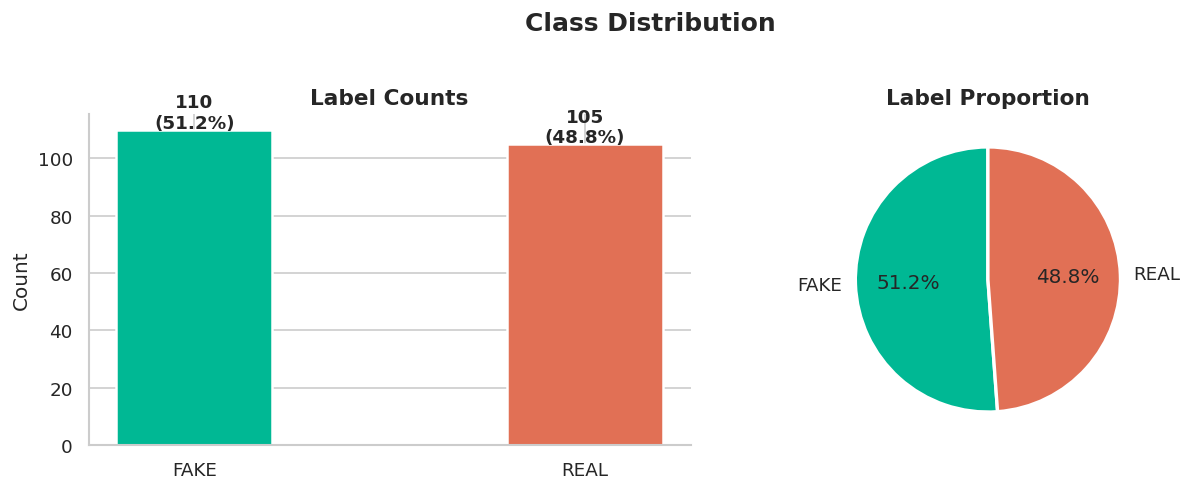

In [4]:
counts = df['label_str'].value_counts()
pcts   = counts / counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
colors = ['#00b894', '#e17055']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5, width=0.4)
for i, (cnt, pct) in enumerate(zip(counts.values, pcts.values)):
    axes[0].text(i, cnt + 0.5, f'{cnt}\n({pct:.1f}%)', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Label Counts', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].spines[['top','right']].set_visible(False)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Label Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Class Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/label_distribution.png', bbox_inches='tight')
plt.show()

## 4. Text Length Analysis

In [5]:
df['word_count'] = df['text'].str.split().str.len()
df['char_count'] = df['text'].str.len()

print(df.groupby('label_str')[['word_count', 'char_count']].describe().round(1).T)

label_str          FAKE   REAL
word_count count  110.0  105.0
           mean    16.7   15.3
           std      1.8    1.9
           min     12.0   11.0
           25%     16.0   14.0
           50%     17.0   15.0
           75%     18.0   17.0
           max     21.0   20.0
char_count count  110.0  105.0
           mean   106.0   99.4
           std      6.5   12.4
           min     87.0   64.0
           25%    102.0   91.0
           50%    106.5   99.0
           75%    110.0  109.0
           max    121.0  127.0


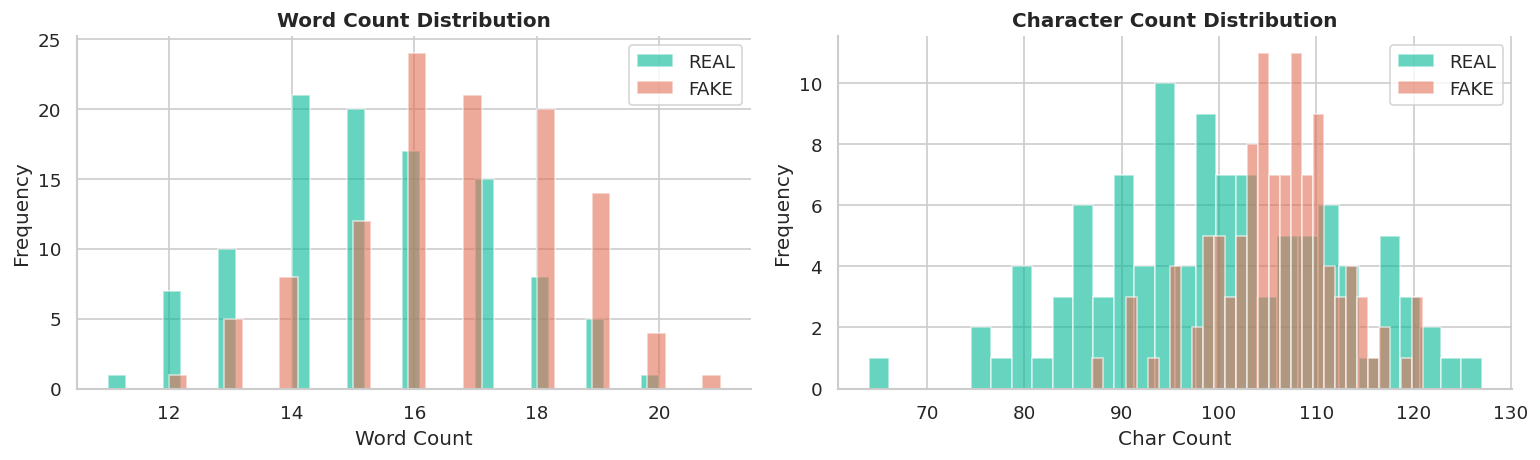

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
palette = {'REAL': '#00b894', 'FAKE': '#e17055'}

for ax, col, title in zip(axes,
                           ['word_count', 'char_count'],
                           ['Word Count Distribution', 'Character Count Distribution']):
    for label, color in palette.items():
        subset = df[df['label_str'] == label][col]
        ax.hist(subset, bins=30, alpha=0.6, color=color, label=label, edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/figures/text_length_distribution.png', bbox_inches='tight')
plt.show()

## 5. Top Words by Class (before preprocessing)

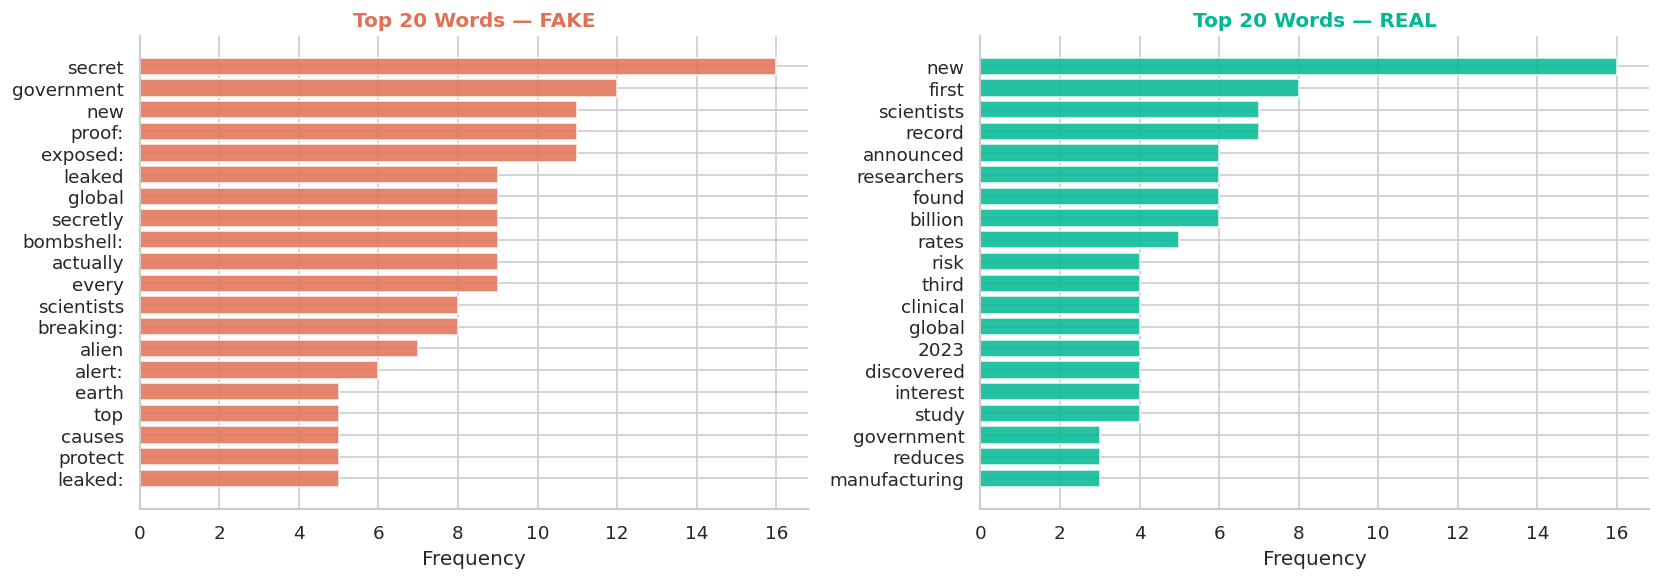

In [7]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)
stop = set(stopwords.words('english'))

def top_words(texts, n=20):
    words = []
    for t in texts:
        words.extend([w.lower() for w in str(t).split() if w.lower() not in stop and len(w) > 2])
    return Counter(words).most_common(n)

fake_top = top_words(df[df['label_str']=='FAKE']['text'])
real_top = top_words(df[df['label_str']=='REAL']['text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, title, color in zip(axes,
    [fake_top, real_top], ['Top 20 Words — FAKE', 'Top 20 Words — REAL'],
    ['#e17055', '#00b894']):
    words, counts = zip(*data)
    ax.barh(words[::-1], counts[::-1], color=color, alpha=0.85)
    ax.set_title(title, fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Frequency')
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/figures/top_words_by_class.png', bbox_inches='tight')
plt.show()

## 6. Key Takeaways

In [8]:
print('Summary')
print('-------')
print(f'Total samples   : {len(df)}')
print(f'FAKE articles   : {(df.label_str=="FAKE").sum()} ({(df.label_str=="FAKE").mean()*100:.1f}%)')
print(f'REAL articles   : {(df.label_str=="REAL").sum()} ({(df.label_str=="REAL").mean()*100:.1f}%)')
print(f'Avg word count  : {df.word_count.mean():.1f}')
print(f'Avg char count  : {df.char_count.mean():.1f}')
print(f'Null values     : {df.isnull().sum().sum()}')
print(f'Duplicates      : {df.duplicated().sum()}')

Summary
-------
Total samples   : 215
FAKE articles   : 110 (51.2%)
REAL articles   : 105 (48.8%)
Avg word count  : 16.0
Avg char count  : 102.8
Null values     : 0
Duplicates      : 0
